In [38]:
import os
import kagglehub
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [39]:
# STEP 1: DOWNLOAD AND LOAD THE DATASET
# =====================================================================
print("--- Step 1: Downloading Dataset via Kagglehub ---")
# Download latest version of the IBM HR Analytics dataset
download_path = kagglehub.dataset_download("pavansubhasht/ibm-hr-analytics-attrition-dataset")
print("Dataset downloaded to folder:", download_path)

# Locate the CSV file inside the downloaded directory
csv_filename = "WA_Fn-UseC_-HR-Employee-Attrition.csv"
full_csv_path = os.path.join(download_path, csv_filename)

# Load into a Pandas DataFrame
df = pd.read_csv(full_csv_path)
print(f"Dataset successfully loaded. Initial Shape: {df.shape}\n")

--- Step 1: Downloading Dataset via Kagglehub ---
Dataset downloaded to folder: /kaggle/input/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset
Dataset successfully loaded. Initial Shape: (1470, 35)



In [40]:
# STEP 2: DATA CLEANING & TARGET ENCODING
# =====================================================================
print("--- Step 2: Cleaning Data & Encoding Target ---")

# Drop redundant or zero-variance columns that do not contribute to learning
redundant_cols = ["EmployeeCount", "Over18", "StandardHours", "EmployeeNumber"]
df.drop(columns=redundant_cols, inplace=True)
print(f"Shape after dropping redundant columns: {df.shape}")

# Convert target variable 'Attrition' from text ('Yes'/'No') to binary integers (1/0)
df["Attrition"] = df["Attrition"].apply(lambda x: 1 if x == "Yes" else 0)

# Display the class distribution to observe the imbalance
print("Target Class Distribution (%) :")
print(df["Attrition"].value_counts(normalize=True) * 100)
print("\n")

--- Step 2: Cleaning Data & Encoding Target ---
Shape after dropping redundant columns: (1470, 31)
Target Class Distribution (%) :
Attrition
0    83.877551
1    16.122449
Name: proportion, dtype: float64




In [41]:
# STEP 3: FEATURE PREPROCESSING (ENCODING & SCALING)
# =====================================================================
print("--- Step 3: Preprocessing Features ---")

# Separate features (X) and target label (y)
X = df.drop(columns=["Attrition"])
y = df["Attrition"]

# Identify numerical and categorical columns automatically
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

# Convert categorical text features into numerical values using One-Hot Encoding
# drop_first=True avoids multi-collinearity (the dummy variable trap)
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Scale the numerical features so they share a uniform range
scaler = StandardScaler()
X_encoded[numerical_cols] = scaler.fit_transform(X_encoded[numerical_cols])

print(f"Final feature space shape after encoding and scaling: {X_encoded.shape}\n")

--- Step 3: Preprocessing Features ---
Final feature space shape after encoding and scaling: (1470, 44)



In [42]:
# STEP 4: TRAIN-TEST SPLIT
# =====================================================================
print("--- Step 4: Splitting Data into Train and Test Sets ---")

# We use 'stratify=y' to ensure both training and testing sets retain 
# the original 84/16 class distribution balance.
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Training Features Shape: {X_train.shape}")
print(f"Testing Features Shape : {X_test.shape}\n")

--- Step 4: Splitting Data into Train and Test Sets ---
Training Features Shape: (1176, 44)
Testing Features Shape : (294, 44)



In [43]:
# STEP 5: MODEL TRAINING
# =====================================================================
print("--- Step 5: Training Classifiers ---")

# Model A: Random Forest Classifier
# We set class_weight='balanced' to natively penalize misclassifications of the minority class (leavers)
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)
print("Random Forest Classifier trained successfully.")

# Model B: Gradient Boosting Classifier
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gb_model.fit(X_train, y_train)
print("Gradient Boosting Classifier trained successfully.\n")

--- Step 5: Training Classifiers ---
Random Forest Classifier trained successfully.
Gradient Boosting Classifier trained successfully.



In [44]:
# STEP 6: EVALUATION METRICS
# =====================================================================
print("--- Step 6: Model Evaluation Metrics ---\n")

def evaluate_classifier(model, name, X_val, y_val):
    predictions = model.predict(X_val)
    
    print("=" * 60)
    print(f" PERFORMANCE METRICS FOR: {name} ")
    print("=" * 60)
    
    # Accuracy Score
    acc = accuracy_score(y_val, predictions)
    print(f"Accuracy Score: {acc:.4f}\n")
    
    # Confusion Matrix
    print("Confusion Matrix:")
    cm = confusion_matrix(y_val, predictions)
    print(f"True Negatives (Stayed): {cm[0][0]}   False Positives: {cm[0][1]}")
    print(f"False Negatives:         {cm[1][0]}   True Positives (Left):   {cm[1][1]}\n")
    
    # Detailed Classification Report (Precision, Recall, F1-Score)
    print("Detailed Classification Report:")
    print(classification_report(y_val, predictions, target_names=["Stayed (0)", "Left (1)"]))
    print("\n")

# Run evaluation for both models
evaluate_classifier(rf_model, "Random Forest (Balanced Weights)", X_test, y_test)
evaluate_classifier(gb_model, "Gradient Boosting Classifier", X_test, y_test)



--- Step 6: Model Evaluation Metrics ---

 PERFORMANCE METRICS FOR: Random Forest (Balanced Weights) 
Accuracy Score: 0.8333

Confusion Matrix:
True Negatives (Stayed): 242   False Positives: 5
False Negatives:         44   True Positives (Left):   3

Detailed Classification Report:
              precision    recall  f1-score   support

  Stayed (0)       0.85      0.98      0.91       247
    Left (1)       0.38      0.06      0.11        47

    accuracy                           0.83       294
   macro avg       0.61      0.52      0.51       294
weighted avg       0.77      0.83      0.78       294



 PERFORMANCE METRICS FOR: Gradient Boosting Classifier 
Accuracy Score: 0.8503

Confusion Matrix:
True Negatives (Stayed): 240   False Positives: 7
False Negatives:         37   True Positives (Left):   10

Detailed Classification Report:
              precision    recall  f1-score   support

  Stayed (0)       0.87      0.97      0.92       247
    Left (1)       0.59      0.21      

/tmp/ipykernel_58/75940938.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[0, 0], x='Attrition', data=df, palette='Set2')
/tmp/ipykernel_58/75940938.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1, 0], x='Attrition', y='MonthlyIncome', data=df, palette='coolwarm')


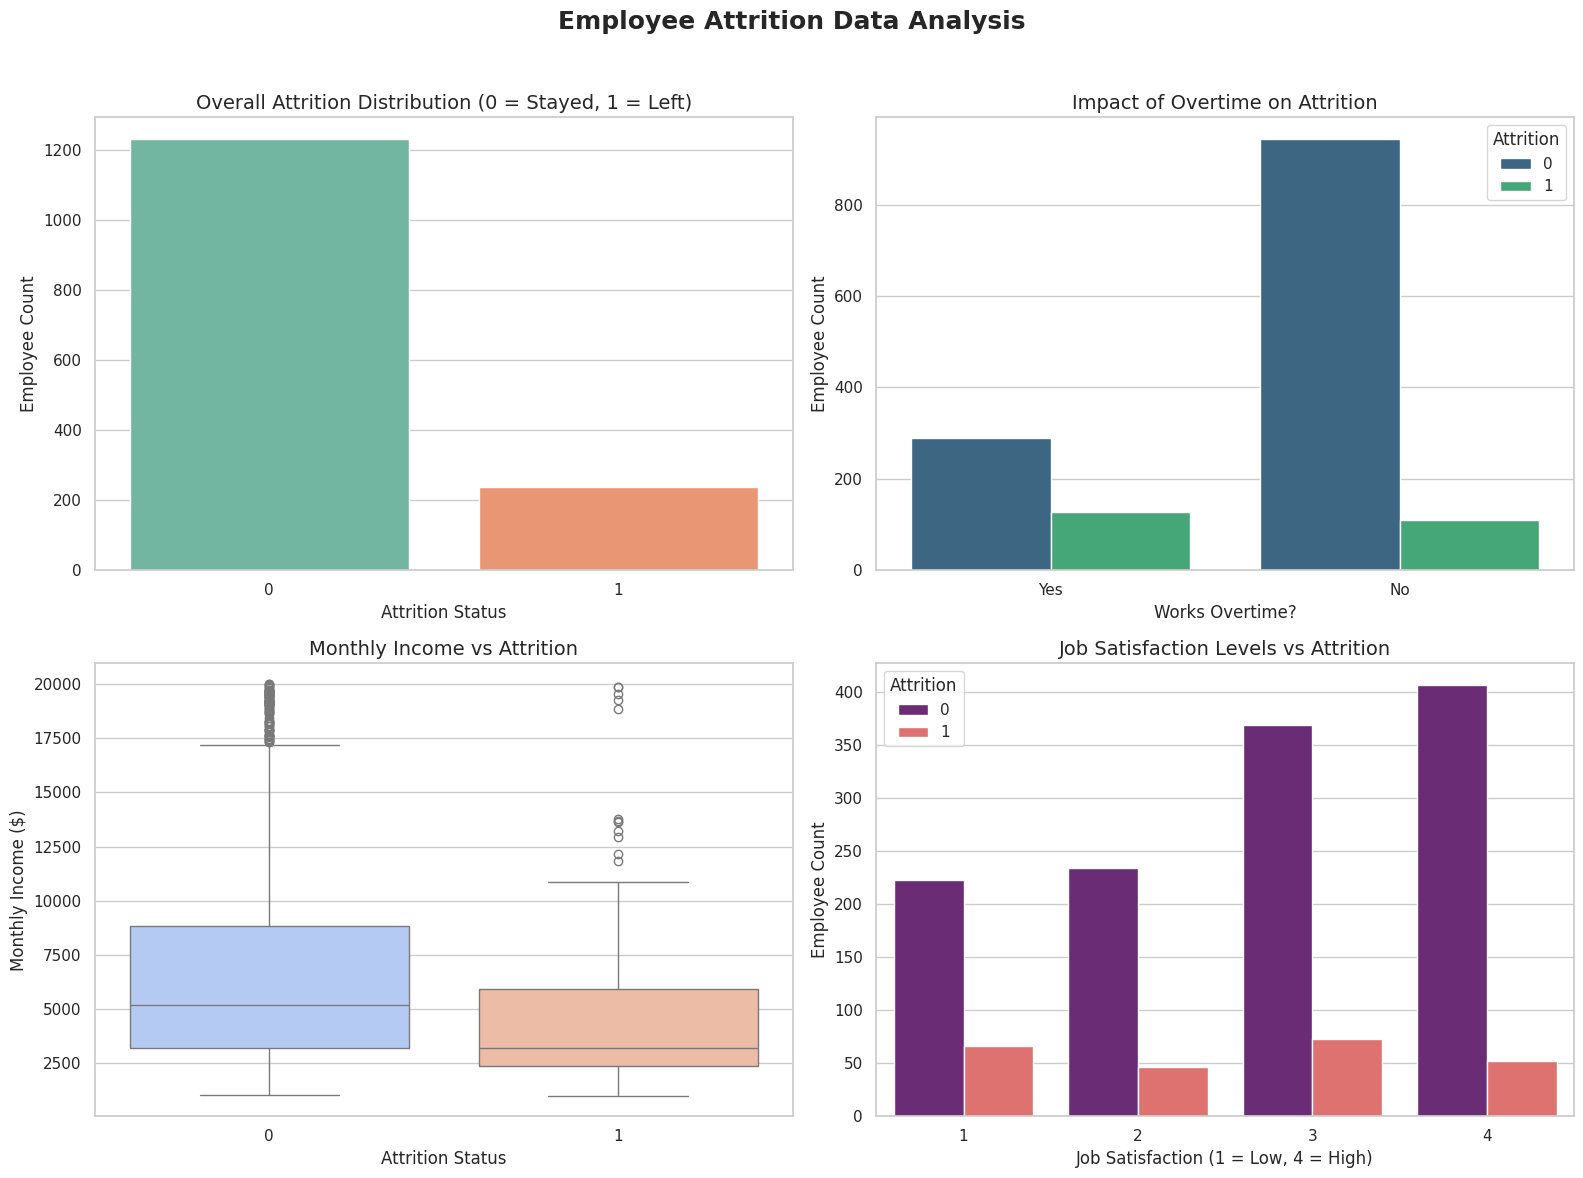

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style for the plots
sns.set_theme(style="whitegrid")

# Create a figure holding multiple plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Employee Attrition Data Analysis", fontsize=18, fontweight='bold')

# Graph 1: Overall Attrition Distribution (Class Imbalance)
sns.countplot(ax=axes[0, 0], x='Attrition', data=df, palette='Set2')
axes[0, 0].set_title("Overall Attrition Distribution (0 = Stayed, 1 = Left)", fontsize=14)
axes[0, 0].set_xlabel("Attrition Status")
axes[0, 0].set_ylabel("Employee Count")

# Graph 2: Overtime vs Attrition (The biggest driver)
sns.countplot(ax=axes[0, 1], x='OverTime', hue='Attrition', data=df, palette='viridis')
axes[0, 1].set_title("Impact of Overtime on Attrition", fontsize=14)
axes[0, 1].set_xlabel("Works Overtime?")
axes[0, 1].set_ylabel("Employee Count")

# Graph 3: Monthly Income vs Attrition (Income Distribution)
sns.boxplot(ax=axes[1, 0], x='Attrition', y='MonthlyIncome', data=df, palette='coolwarm')
axes[1, 0].set_title("Monthly Income vs Attrition", fontsize=14)
axes[1, 0].set_xlabel("Attrition Status")
axes[1, 0].set_ylabel("Monthly Income ($)")

# Graph 4: Job Satisfaction vs Attrition
sns.countplot(ax=axes[1, 1], x='JobSatisfaction', hue='Attrition', data=df, palette='magma')
axes[1, 1].set_title("Job Satisfaction Levels vs Attrition", fontsize=14)
axes[1, 1].set_xlabel("Job Satisfaction (1 = Low, 4 = High)")
axes[1, 1].set_ylabel("Employee Count")

# Adjust layout and display the graphs
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [46]:
# STEP 7: FEATURE IMPORTANCE (INSIGHT EXTRACTION)
# =====================================================================
print("--- Step 7: Extracting Top Predictors of Attrition ---")

# Extract feature importances from the Random Forest model
importances = rf_model.feature_importances_
feature_names = X_encoded.columns

# Create a clean DataFrame to map names to scores
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Display the top 10 core factors driving employee attrition
print("Top 10 Most Influential Features Driving Attrition:")
print(importance_df.head(10).to_string(index=False))

--- Step 7: Extracting Top Predictors of Attrition ---
Top 10 Most Influential Features Driving Attrition:
             Feature  Importance
       MonthlyIncome    0.075157
                 Age    0.068066
   TotalWorkingYears    0.053865
           DailyRate    0.052450
      YearsAtCompany    0.048968
         MonthlyRate    0.047673
          HourlyRate    0.044192
    DistanceFromHome    0.043070
YearsWithCurrManager    0.042613
        OverTime_Yes    0.042462


In [47]:
# =====================================================================
# STEP 8: MAKING ACTUAL PREDICTIONS ON INDIVIDUAL EMPLOYEES
# =====================================================================
print("\n--- Step 8: Making Individual Predictions ---")

# Let's select a few sample profiles from the test set to inspect closely
# Index 0, 5, and 10 from the test split
sample_indices = [0, 5, 10]

for i, idx in enumerate(sample_indices):
    # Extract the feature row for a single employee
    employee_profile = X_test.iloc[[idx]]
    
    # Grab their actual true status from the ground-truth labels
    true_status = y_test.iloc[idx]
    true_text = "Left the Company" if true_status == 1 else "Stayed with Company"
    
    # 1. Generate the final prediction (0 or 1) using Random Forest
    rf_pred = rf_model.predict(employee_profile)[0]
    pred_text = "RISK ALERT: Highly Likely to Leave" if rf_pred == 1 else "Safe: Likely to Stay"
    
    # 2. Extract the prediction probabilities
    # predict_proba returns an array: [probability of 0 (Stay), probability of 1 (Leave)]
    probabilities = rf_model.predict_proba(employee_profile)[0]
    confidence = probabilities[rf_pred] * 100
    
    # Print out a clean, readable report for HR simulation
    print("-" * 50)
    print(f"HR Assessment Report - Employee Profile Sample #{i+1}")
    print("-" * 50)
    print(f"Actual Ground Truth : {true_text}")
    print(f"Model Prediction    : {pred_text}")
    print(f"Model Confidence    : {confidence:.2f}%")
    print(f"Breakdown           : [Stay Prob: {probabilities[0]*100:.1f}% | Leave Prob: {probabilities[1]*100:.1f}%]")
print("-" * 50)


--- Step 8: Making Individual Predictions ---
--------------------------------------------------
HR Assessment Report - Employee Profile Sample #1
--------------------------------------------------
Actual Ground Truth : Stayed with Company
Model Prediction    : RISK ALERT: Highly Likely to Leave
Model Confidence    : 63.00%
Breakdown           : [Stay Prob: 37.0% | Leave Prob: 63.0%]
--------------------------------------------------
HR Assessment Report - Employee Profile Sample #2
--------------------------------------------------
Actual Ground Truth : Stayed with Company
Model Prediction    : Safe: Likely to Stay
Model Confidence    : 89.00%
Breakdown           : [Stay Prob: 89.0% | Leave Prob: 11.0%]
--------------------------------------------------
HR Assessment Report - Employee Profile Sample #3
--------------------------------------------------
Actual Ground Truth : Stayed with Company
Model Prediction    : Safe: Likely to Stay
Model Confidence    : 92.00%
Breakdown          

In [48]:
# =====================================================================
# STEP 10: CONTINUOUS INTERACTIVE USER-INPUT SANDBOX WITH CLEAN EXIT
# =====================================================================

def live_interactive_sandbox():
    while True:
        print("\n" + "="*60)
        print("      LAUNCHING LIVE EMPLOYEE RISK ASSESSMENT ENGINE       ")
        print("="*60)
        print("Please enter the requested employee data below (or type 'exit' to quit):\n")
        
        # 1. Start with a clean average baseline row from the existing dataset
        custom_profile = X.iloc[[0]].copy()
        
        # Set safe default baseline values for minor features to prevent scale distortions
        for col in numerical_cols:
            custom_profile.at[custom_profile.index[0], col] = int(X[col].median())
        for col in categorical_cols:
            custom_profile.at[custom_profile.index[0], col] = X[col].mode()[0]
            
        # 2. Safely collect dynamic user inputs via terminal prompt
        try:
            # Input Age
            age_in = input("1. Enter Employee Age (e.g., 18 to 65): ").strip()
            if age_in.lower() == 'exit':
                print("\nGood prediction! Thanks for using the assessment engine.")
                break
            custom_profile.at[custom_profile.index[0], "Age"] = int(age_in)
            
            # Input Overtime
            ot_in = input("2. Does the employee work Overtime? (Enter 'Yes' or 'No'): ").strip().capitalize()
            if ot_in.lower() == 'exit':
                print("\nGood prediction! Thanks for using the assessment engine.")
                break
            while ot_in not in ['Yes', 'No']:
                ot_in = input("   Invalid input! Please enter exactly 'Yes' or 'No': ").strip().capitalize()
                if ot_in.lower() == 'exit':
                    break
            if ot_in.lower() == 'exit':
                print("\nGood prediction! Thanks for using the assessment engine.")
                break
            custom_profile.at[custom_profile.index[0], "OverTime"] = ot_in
            
            # Input Monthly Income in Rupees (Rs.)
            income_rs = input("3. Enter Monthly Salary in Rupees RS: ").strip()
            if income_rs.lower() == 'exit':
                print("\nGood prediction! Thanks for using the assessment engine.")
                break
            # Convert Rupees back to USD equivalents to keep model predictions tracking accurately
            income_usd = int(income_rs) / 278.0
            custom_profile.at[custom_profile.index[0], "MonthlyIncome"] = int(income_usd)
            
            # Input Distance From Home
            dist_in = input("4. Distance from Home in miles/km (e.g., 1 to 30): ").strip()
            if dist_in.lower() == 'exit':
                print("\nGood prediction! Thanks for using the assessment engine.")
                break
            custom_profile.at[custom_profile.index[0], "DistanceFromHome"] = int(dist_in)
            
            # Input Job Satisfaction (Updated Scale Labels)
            sat_in = input("5. Job Satisfaction Score (Enter 1=Fair, 2=Good, 3=Very Good, 4=Excellent): ").strip()
            if sat_in.lower() == 'exit':
                print("\nGood prediction! Thanks for using the assessment engine.")
                break
            while sat_in not in ['1', '2', '3', '4']:
                sat_in = input("   Invalid score! Enter an integer between 1 and 4: ").strip()
                if sat_in.lower() == 'exit':
                    break
            if sat_in.lower() == 'exit':
                print("\nGood prediction! Thanks for using the assessment engine.")
                break
            custom_profile.at[custom_profile.index[0], "JobSatisfaction"] = int(sat_in)
            
        except ValueError:
            print("\n❌ Error: Invalid numerical input format entered. Restarting input screen...")
            continue

        # 3. Process categorical strings into standard machine-readable binary columns
        combined_df = pd.concat([X, custom_profile], axis=0)
        combined_encoded = pd.get_dummies(combined_df, columns=categorical_cols, drop_first=True)
        
        processed_user_row = combined_encoded.iloc[[-1]].copy()
        
        # 4. Scale continuous numeric features matching your training scales
        processed_user_row[numerical_cols] = scaler.transform(processed_user_row[numerical_cols])
        
        # 5. Calculate pipeline predictions
        prediction = rf_model.predict(processed_user_row)[0]
        probabilities = rf_model.predict_proba(processed_user_row)[0]
        
        # Map input satisfaction back to label text for output screen
        satisfaction_labels = {"1": "Fair", "2": "Good", "3": "Very Good", "4": "Excellent"}
        sat_text = satisfaction_labels[sat_in]

        # 6. Print Risk Evaluation Report
        risk_status = "❌ RISK ALERT: High Attrition Vulnerability" if prediction == 1 else "✅ SAFE: High Retention Probability"
        confidence = probabilities[prediction] * 100
        
        print("\n" + "-"*60)
        print("             REAL-TIME PREDICTION RESULTS                 ")
        print("-" * 60)
        print(f"Age: {age_in} | Overtime: {ot_in} | Salary: RS {int(income_rs):,} | Distance: {dist_in}mi | Satisfaction: {sat_text}")
        print("-" * 60)
        print(f"Status Evaluation : {risk_status}")
        print(f"Model Confidence  : {confidence:.2f}%")
        print(f"Stay Probability  : {probabilities[0]*100:.1f}%")
        print(f"Leave Probability : {probabilities[1]*100:.1f}%")
        print("="*60 + "\n")
        
        # 7. Ask to continue or quit directly after completion
        next_step = input("Press Enter to test another profile, or type 'exit' to quit: ").strip().lower()
        if next_step == 'exit':
            print("\nGood prediction! Thanks for using the assessment engine.")
            break

# Run the live interactive loop
live_interactive_sandbox()


      LAUNCHING LIVE EMPLOYEE RISK ASSESSMENT ENGINE       
Please enter the requested employee data below (or type 'exit' to quit):



1. Enter Employee Age (e.g., 18 to 65):  44
2. Does the employee work Overtime? (Enter 'Yes' or 'No'):  Yes
3. Enter Monthly Salary in Rupees RS:  40000
4. Distance from Home in miles/km (e.g., 1 to 30):  24
5. Job Satisfaction Score (Enter 1=Fair, 2=Good, 3=Very Good, 4=Excellent):  3



------------------------------------------------------------
             REAL-TIME PREDICTION RESULTS                 
------------------------------------------------------------
Age: 44 | Overtime: Yes | Salary: RS 40,000 | Distance: 24mi | Satisfaction: Very Good
------------------------------------------------------------
Status Evaluation : ✅ SAFE: High Retention Probability
Model Confidence  : 84.00%
Stay Probability  : 84.0%
Leave Probability : 16.0%



Press Enter to test another profile, or type 'exit' to quit:  exit



Good prediction! Thanks for using the assessment engine.


In [49]:
import joblib

print("\n--- Saving Project Files ---")

# 1. Save the trained Random Forest model
model_filename = "attrition_rf_model.joblib"
joblib.dump(rf_model, model_filename)
print(f"✅ Trained model successfully saved as: {model_filename}")

# 2. Save the fitted Standard Scaler (Crucial for preprocessing future sandbox inputs)
scaler_filename = "attrition_scaler.joblib"
joblib.dump(scaler, scaler_filename)
print(f"✅ Fitted scaler successfully saved as: {scaler_filename}")


--- Saving Project Files ---
✅ Trained model successfully saved as: attrition_rf_model.joblib
✅ Fitted scaler successfully saved as: attrition_scaler.joblib
